<a href="https://colab.research.google.com/github/swanjala849-Mas/Machine-Learning/blob/main/Cost_Optimized_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
# Seed for reproducibility (simulated)
np.random.seed(42)
n_samples = 1000
# Features: Farm Size (Acres), Historical Yield (Bags), M-Pesa Savings Consistency Score
(0-100)
farm_size = np.random.exponential(scale=2.5, size=n_samples)
historical_yield = farm_size * np.random.normal(loc=15, scale=3, size=n_samples)
savings_score = np.random.uniform(low=10, high=100, size=n_samples)

In [3]:
# Non-linear latent risk factor unique to this lab
risk_latent = (0.5 * (savings_score < 40)) - (0.2 * farm_size) + np.random.normal(0, 0.5,
n_samples)
default_prob = 1 / (1 + np.exp(-risk_latent))
default_label = (np.random.random(n_samples) < default_prob).astype(int)
df = pd.DataFrame({
'farm_size_acres': farm_size,
'historical_yield_bags': historical_yield,
'mpesa_savings_score': savings_score,
'defaulted': default_label
})
X = df[['farm_size_acres', 'historical_yield_bags', 'mpesa_savings_score']]
y = df['defaulted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
df.head()

,farm_size_acres,historical_yield_bags,mpesa_savings_score,defaulted
0,1.173170,18.222974,97.437942,1
1,7.525304,82.732939,39.821231,0
2,3.291864,53.132643,53.383695,0
3,2.282356,38.416069,27.648794,0
4,0.424062,7.073091,64.970206,0


In [6]:
#@title Code -  Fit and Evaluate Standard Logistic Regression
# Initialize the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model training complete!")
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

Model training complete!
Model coefficients: [[-0.36618817  0.00809137 -0.00317123]]
Model intercept: [0.36857518]


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predicted probabilities for both classes
y_prob = model.predict_proba(X_test)
y_prob_default = y_prob[:, 1]
# Standard hard predictions using threshold 0.5
y_pred_standard = model.predict(X_test)
# Display model performance
print("Accuracy:", round(
    accuracy_score(y_test, y_pred_standard), 4
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_standard))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_standard,
    zero_division=0
))

Accuracy: 0.5233

Confusion Matrix:
[[108  44]
 [ 99  49]]

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.71      0.60       152
           1       0.53      0.33      0.41       148

    accuracy                           0.52       300
   macro avg       0.52      0.52      0.50       300
weighted avg       0.52      0.52      0.51       300



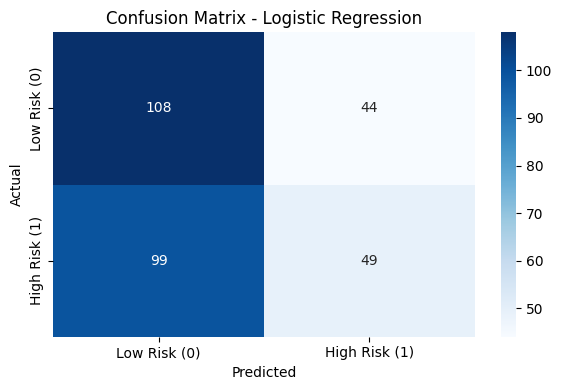

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate predictions using the trained model
y_pred = model.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Risk (0)', 'High Risk (1)'],
    yticklabels=['Low Risk (0)', 'High Risk (1)']
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

In [12]:
#@title Code -  Probability vs. Hard Label Tabulation & Custom Thresholding
# Create the comparison table

results = X_test.copy()

results['Actual_Default'] = y_test
results['Predicted_Probability'] = y_prob_default
results['Standard_Prediction'] = y_pred_standard

# Display the first 10 samples
print("First 10 test samples: Actual vs Predicted")

display(
    results.head(10).style.format({
        'farm_size_acres': '{:.2f}',
        'historical_yield_bags': '{:.2f}',
        'mpesa_savings_score': '{:.2f}',
        'Predicted_Probability': '{:.4f}'
    })
)

First 10 test samples: Actual vs Predicted


,farm_size_acres,historical_yield_bags,mpesa_savings_score,Actual_Default,Predicted_Probability,Standard_Prediction
521,1.20,21.55,24.55,1,0.5065,1
737,4.24,71.63,39.92,0,0.3249,0
740,1.55,28.98,95.00,0,0.4337,0
660,1.10,18.70,56.25,0,0.4846,0
411,7.49,82.40,38.07,0,0.1384,0
678,8.72,164.59,87.09,0,0.1455,0
626,1.55,16.66,75.64,1,0.4244,0
513,5.03,88.03,27.11,1,0.3004,0
859,0.17,2.00,43.16,0,0.5463,1
136,1.83,30.76,78.06,0,0.4256,0


In [13]:
# Define the cost function

FP_COST = 15000
FN_COST = 3000

def calculate_financial_cost(y_true, y_pred):


    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    total_cost = (FP_COST * fp) + (FN_COST * fn)

    return {
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Total_Cost_KES': total_cost
    }
# Calculate cost using the standard 0.5 threshold
standard_cost = calculate_financial_cost(
    y_test,
    y_pred_standard
)
print("Results at the standard threshold of 0.50")

for key, value in standard_cost.items():
    print(f"{key}: {value:,}")

Results at the standard threshold of 0.50
TN: 108
FP: 44
FN: 99
TP: 49
Total_Cost_KES: 957,000


In [14]:
# Generate thresholds from 0.10 to 0.90
thresholds = np.round(
    np.arange(0.10, 0.901, 0.05), 2
)

cost_results = []

for threshold in thresholds:

    # Convert probabilities to hard labels
    y_pred_custom = (
        y_prob_default >= threshold
    ).astype(int)

    # Calculate financial cost
    metrics = calculate_financial_cost(
        y_test,
        y_pred_custom
    )

    # Store results
    cost_results.append({
        'Threshold': threshold,
        **metrics
    })

# Convert results to a DataFrame
cost_df = pd.DataFrame(cost_results)
display(
    cost_df.style.format({
        'Threshold': '{:.2f}',
        'Total_Cost_KES': 'KES {:,.0f}'
    })
)

,Threshold,TN,FP,FN,TP,Total_Cost_KES
0,0.10,3,149,0,148,"KES 2,235,000"
1,0.15,11,141,2,146,"KES 2,121,000"
2,0.20,15,137,6,142,"KES 2,073,000"
3,0.25,22,130,9,139,"KES 1,977,000"
4,0.30,37,115,14,134,"KES 1,767,000"
5,0.35,46,106,25,123,"KES 1,665,000"
6,0.40,63,89,37,111,"KES 1,446,000"
7,0.45,85,67,67,81,"KES 1,206,000"
8,0.50,108,44,99,49,"KES 957,000"
9,0.55,144,8,138,10,"KES 534,000"


In [15]:
# Find the row with the minimum total cost
min_cost_row = cost_df.loc[cost_df['Total_Cost_KES'].idxmin()]

print("Optimal Threshold for Minimum Cost:")
print(f"Threshold: {min_cost_row['Threshold']:.2f}")
print(f"Minimum Cost: KES {min_cost_row['Total_Cost_KES']:,.0f}")
print(f"Confusion Matrix metrics at this threshold:")
print(f"  True Negatives (TN): {int(min_cost_row['TN'])}")
print(f"  False Positives (FP): {int(min_cost_row['FP'])}")
print(f"  False Negatives (FN): {int(min_cost_row['FN'])}")
print(f"  True Positives (TP): {int(min_cost_row['TP'])}")

Optimal Threshold for Minimum Cost:
Threshold: 0.60
Minimum Cost: KES 444,000
Confusion Matrix metrics at this threshold:
  True Negatives (TN): 152
  False Positives (FP): 0
  False Negatives (FN): 148
  True Positives (TP): 0


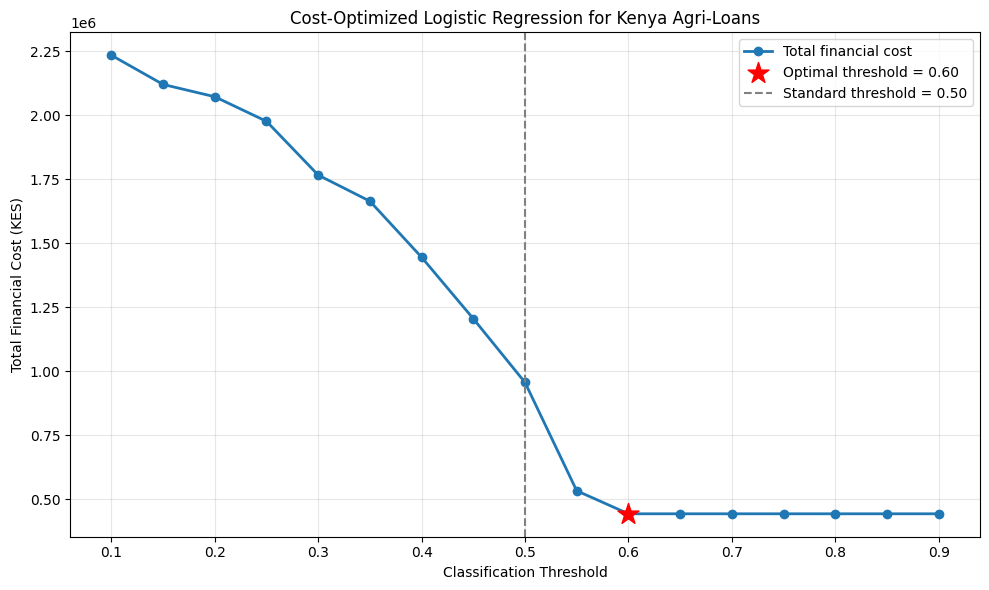

In [17]:
# Extract optimal values from min_cost_row to fix the NameError
optimal_threshold = min_cost_row['Threshold']
minimum_cost = min_cost_row['Total_Cost_KES']

# Plot total financial cost against classification threshold
plt.figure(figsize=(10, 6))

plt.plot(
    cost_df['Threshold'],
    cost_df['Total_Cost_KES'],
    marker='o',
    linewidth=2,
    label='Total financial cost'
)

# Mark the minimum-cost threshold
plt.scatter(
    optimal_threshold,
    minimum_cost,
    marker='*',
    s=250,
    color='red',
    zorder=5,
    label=f'Optimal threshold = {optimal_threshold:.2f}'
)

# Mark the standard threshold cost
plt.axvline(
    x=0.50,
    linestyle='--',
    color='gray',
    label='Standard threshold = 0.50'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Total Financial Cost (KES)')
plt.title('Cost-Optimized Logistic Regression for Kenya Agri-Loans')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of the Cost Curve

This cost curve illustrates the trade-off between the classification threshold and the total financial cost (in KES) of our credit decisions under asymmetric costs (FP = KES 15,000 vs. FN = KES 3,000).

#### 1. High Cost on the Left (Thresholds < 0.50)
* **Overly Aggressive Approval:** When the threshold is low, the model approves almost every borrower. This yields a massive number of **False Positives (FPs)**—approving loans for borrowers who default.
* **Financial Consequence:** Because a single False Positive is highly expensive (**KES 15,000**), incorrect approvals dominate the risk and drive the total financial cost to over **KES 2,000,000**.

#### 2. The Steep Decline (Thresholds 0.50 to 0.60)
* **Shifting to Conservative Approvals:** As we raise the threshold toward 0.60, the model becomes stricter. It starts rejecting riskier borrowers, eliminating the highly expensive False Positives.
* **Financial Consequence:** Although a higher threshold increases **False Negatives (FNs)** (rejecting safe borrowers), each FN only costs **KES 3,000**. Minimizing the KES 15,000 defaults far outweighs the lost opportunity of KES 3,000, causing a sharp drop in total costs.

#### 3. The Flat Plateau on the Right (Thresholds ≥ 0.60)
* **Zero Risk Threshold:** At a threshold of **0.60** and above, the model's highest predicted probability for default is below the threshold. Consequently, the model classifies *everyone* as Low Risk (0 predicted defaults), approving nobody.
* **Financial Consequence:** The model makes zero positive predictions, yielding **0 False Positives** and **148 False Negatives**. The total cost stabilizes at exactly `148 * KES 3,000 = KES 444,000`.

#### Summary
Because the underlying predictive power of this baseline Logistic Regression model is weak, the cost-minimizing threshold of **0.60** opts to reject all high-risk loans entirely to shield the business from expensive defaults.

In [19]:
# Predictions using the optimal threshold
y_pred_optimal = (
    y_prob_default >= optimal_threshold
).astype(int)

print("Optimized Model Classification Report")
print(
    classification_report(
        y_test,
        y_pred_optimal,
        zero_division=0
    )
)

print("Optimized Confusion Matrix")
print(
    confusion_matrix(
        y_test,
        y_pred_optimal,
        labels=[0, 1]
    )
)

Optimized Model Classification Report
              precision    recall  f1-score   support

           0       0.51      1.00      0.67       152
           1       0.00      0.00      0.00       148

    accuracy                           0.51       300
   macro avg       0.25      0.50      0.34       300
weighted avg       0.26      0.51      0.34       300

Optimized Confusion Matrix
[[152   0]
 [148   0]]


In criminal justice, a false positive occurs when an innocent person is incorrectly classified as guilty or convicted of a crime. This error can result in wrongful imprisonment, reputational damage, loss of employment, and separation from family. A false negative occurs when a guilty person is incorrectly classified as innocent or acquitted, which can undermine public safety and justice. In cases where the evidence is uncertain, the serious consequences of wrongful conviction support the use of strong evidentiary safeguards and fair trial procedures
